### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from datetime import datetime, timedelta

### Download Stock Data

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ticker = []
while True:
    input_ticker = input("Enter stock ticker (or 'exit' to quit): ").upper()
    if input_ticker == "EXIT":
        break
    else:
        ticker.append(input_ticker)
start_date = "2020-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")
df = yf.download(ticker, start=start_date,end=end_date)
df=df[['Close']].dropna()

[*********************100%***********************]  1 of 1 completed


In [4]:
scaler = StandardScaler()

df["Close"] = scaler.fit_transform(df[["Close"]])

In [5]:
df.Close

Ticker,AAPL
Date,
2020-01-02,-1.846217
2020-01-03,-1.859934
2020-01-06,-1.848800
2020-01-07,-1.855424
2020-01-08,-1.832875
...,...
2026-02-19,1.821085
2026-02-20,1.899039
2026-02-23,1.930220


In [6]:
seq_length = 30
data = []
for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length].values)
    
data = np.array(data)
train_size = int(len(data) * 0.8)
X_train = torch.from_numpy(data[:train_size, :-1,:]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1,:]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1,:]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1,:]).type(torch.Tensor).to(device)

In [7]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout= 0.1)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        out, (hn,cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

In [8]:
model = PredictionModel(input_dim=1, hidden_dim=64, num_layers=3, output_dim=1).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
num_epochs = 200
for i in range(num_epochs):
    model.train()
    y_train_pred = model(X_train.float().to(device))
    optimizer.zero_grad()
    loss = criterion(y_train_pred, y_train.float().to(device))
    loss.backward()
    optimizer.step()
    
    if (i+1) % 20 == 0:
        print(f'Epoch [{i+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [20/200], Loss: 0.1869
Epoch [40/200], Loss: 0.0581
Epoch [60/200], Loss: 0.0135
Epoch [80/200], Loss: 0.0124
Epoch [100/200], Loss: 0.0112
Epoch [120/200], Loss: 0.0109
Epoch [140/200], Loss: 0.0106
Epoch [160/200], Loss: 0.0102
Epoch [180/200], Loss: 0.0097
Epoch [200/200], Loss: 0.0094


In [10]:
model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [11]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [12]:
train_rmse

4.9799876

In [13]:
test_rmse

14.960191

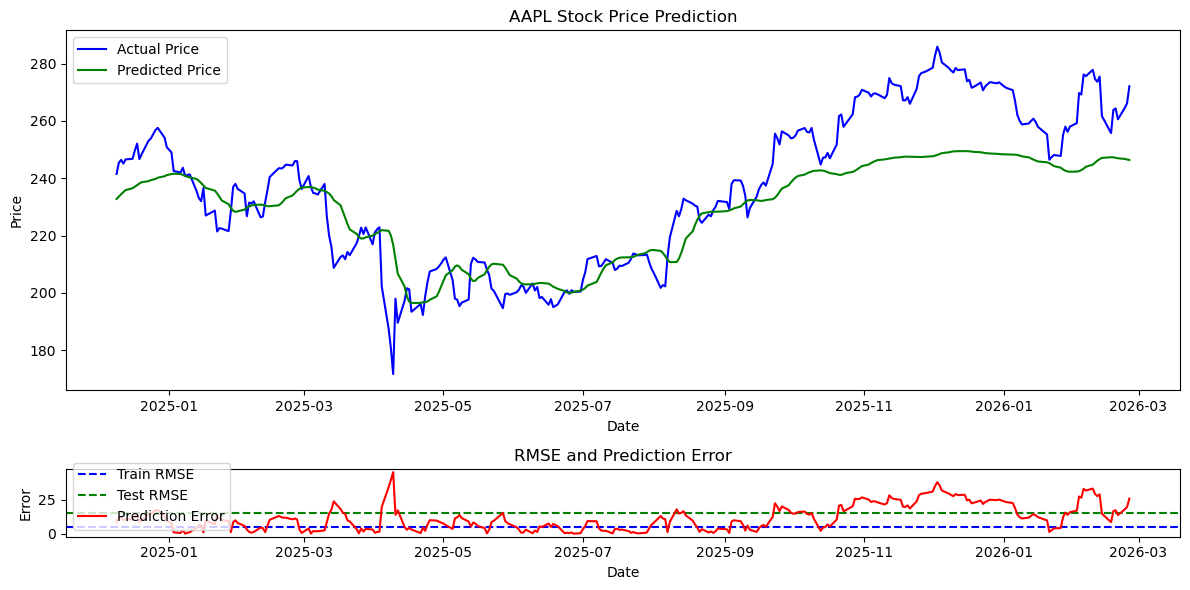

In [14]:
fig = plt.figure(figsize=(12,6))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[len(df) - len(y_test):].index, y_test,color="blue", label="Actual Price")
ax1.plot(df.iloc[len(df) - len(y_test):].index, y_test_pred,color="green", label="Predicted Price")
ax1.set_title(f"{ticker} Stock Price Prediction")
ax1.legend()
plt.xlabel("Date")
plt.ylabel("Price")

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(train_rmse, color="blue", linestyle="--", label="Train RMSE")
ax2.axhline(test_rmse, color="green", linestyle="--", label="Test RMSE")
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), "r", label="Prediction Error")
ax2.legend()
plt.title("RMSE and Prediction Error")
plt.xlabel("Date")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

In [15]:
import sys
import yfinance as yf
print(sys.executable)
print(yf.__version__)

c:\ProgramData\anaconda3\python.exe
1.2.0
